# 📊 NSE Institutional Flow & Sentiment Engine
**Automated Daily ETL Pipeline & Market Impact Dashboard**

This notebook ingests raw daily FII/DII cash market data, cleanses the formatting, merges it with historical Nifty 50 closing prices, and generates actionable market intelligence including streak tracking and net sentiment analysis.

In [81]:
import pandas as pd

# The final, clean load of your February data
# We use forward slashes (/) to keep Python happy on Windows
df = pd.read_csv('../data/fii_history_2026-02.csv')

# Look at the first 5 rows to make sure the columns are correct
print("✅ Project Database: Connected")
df.head()

✅ Project Database: Connected


,FII Rs Crores,Unnamed: 1,Unnamed: 2,DII Rs Crores,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Date,Gross Purchase,Gross Sales,Net Purchase / Sales,Gross Purchase,Gross Sales,Net Purchase / Sales
1,Total,339315.95,345956.73,-6640.78,346722.22,308299.11,38423.11
2,27-Feb-2026,"36,699.66","44,236.02","-7,536.36","24,867.72","12,574.91","12,292.81"
3,26-Feb-2026,"14,607.90","18,073.89","-3,465.99","19,242.72","14,211.15","5,031.57"
4,25-Feb-2026,"30,369.48","27,377.84","2,991.64","18,346.49","13,227.92","5,118.57"


In [82]:
# 1. Skip the junk headers and rename
df_clean = df.iloc[2:].copy()
df_clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']

# 2. Reset the index
df_clean = df_clean.reset_index(drop=True)

# 3. THE FIX: Remove commas and whitespace before converting to numbers
cols_to_fix = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']

for col in cols_to_fix:
    # This line removes commas and extra spaces
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '').str.strip()
    # Now we convert to actual numbers
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("✅ Stage 2: Data Cleaning Complete (Commas Removed)")
df_clean.head()

✅ Stage 2: Data Cleaning Complete (Commas Removed)


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,27-Feb-2026,36699.66,44236.02,-7536.36,24867.72,12574.91,12292.81
1,26-Feb-2026,14607.90,18073.89,-3465.99,19242.72,14211.15,5031.57
2,25-Feb-2026,30369.48,27377.84,2991.64,18346.49,13227.92,5118.57
3,24-Feb-2026,20550.91,20653.44,-102.53,18580.96,15419.74,3161.22
4,23-Feb-2026,15294.02,11810.32,3483.70,12360.86,13653.10,-1292.24


In [83]:
# Calculate Total Net Flows
fii_net_total = df_clean['FII_Net'].sum()
dii_net_total = df_clean['DII_Net'].sum()

print(f"📊 FEBRUARY 2026 MARKET SUMMARY")
print(f"-------------------------------")
print(f"FII Net Movement: {fii_net_total:,.2f} Cr")
print(f"DII Net Movement: {dii_net_total:,.2f} Cr")

# Logic to determine who is driving the market
if fii_net_total < 0 and dii_net_total > 0:
    print("\n⚠️ TREND: FIIs are exiting, but DIIs are absorbing the pressure.")
elif fii_net_total > 0:
    print("\n🚀 TREND: FIIs are bullish. Global money is flowing in!")

📊 FEBRUARY 2026 MARKET SUMMARY
-------------------------------
FII Net Movement: -6,640.78 Cr
DII Net Movement: 38,423.11 Cr

⚠️ TREND: FIIs are exiting, but DIIs are absorbing the pressure.


In [84]:
# 1. Find the 3 biggest selling days by FIIs
top_selling = df_clean.sort_values(by='FII_Net', ascending=True).head(3)

# 2. Find the 3 biggest buying days by FIIs
top_buying = df_clean.sort_values(by='FII_Net', ascending=False).head(3)

print("🚨 TOP 3 PANIC DAYS (Highest FII Selling):")
print(top_selling[['Date', 'FII_Net']])

print("\n💎 TOP 3 ACCUMULATION DAYS (Highest FII Buying):")
print(top_buying[['Date', 'FII_Net']])

🚨 TOP 3 PANIC DAYS (Highest FII Selling):
           Date  FII_Net
0   27-Feb-2026 -7536.36
10  13-Feb-2026 -7395.41
1   26-Feb-2026 -3465.99

💎 TOP 3 ACCUMULATION DAYS (Highest FII Buying):
           Date  FII_Net
18  03-Feb-2026  5236.28
4   23-Feb-2026  3483.70
2   25-Feb-2026  2991.64


In [85]:
# Save the cleaned Feb data as the foundation of your Master DB
df_clean.to_csv('../data/fii_dii_master_database.csv', index=False)

print("🗄️ Master Database Initialized: C:/dev/nse-market-intelligence-suite/data/fii_dii_master_database.csv")

🗄️ Master Database Initialized: C:/dev/nse-market-intelligence-suite/data/fii_dii_master_database.csv


In [86]:
import pandas as pd

# 1. The Pro-Cleaning Function
def clean_month(file_path):
    raw = pd.read_csv(file_path)
    # Skip the junk headers from the website copy-paste
    clean = raw.iloc[2:].copy()
    clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    
    # Scrub commas and fix numbers
    cols = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    for col in cols:
        clean[col] = clean[col].astype(str).str.replace(',', '').str.strip()
        clean[col] = pd.to_numeric(clean[col], errors='coerce')
    
    return clean.dropna(subset=['Date'])

# 2. Build the database by stacking the months
print("🏗️ Building Master Database...")

# Process each raw file
jan = clean_month('../data/fii_raw_jan_2026.csv')
feb = clean_month('../data/fii_history_2026-02.csv')
mar = clean_month('../data/fii_raw_march_2026.csv')

# Stack them vertically
master_df = pd.concat([mar, feb, jan], ignore_index=True)

# 3. Final Polish
master_df = master_df.drop_duplicates(subset=['Date'])
master_df.to_csv('../data/fii_dii_master_database.csv', index=False)

print(f"✅ SUCCESS! Your database now has {len(master_df)} trading days.")
print("Dates covered:", master_df['Date'].min(), "to", master_df['Date'].max())
master_df.head(10)

🏗️ Building Master Database...
✅ SUCCESS! Your database now has 60 trading days.
Dates covered: 01-Feb-2026 to 30-Mar-2026


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,13-Mar-2026,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42
1,12-Mar-2026,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77
2,11-Mar-2026,11448.68,17715.99,-6267.31,16044.16,11078.63,4965.53
3,10-Mar-2026,13188.32,17860.96,-4672.64,17202.49,10869.23,6333.26
4,09-Mar-2026,11156.99,17502.56,-6345.57,21586.46,12572.66,9013.80
5,06-Mar-2026,14434.69,20465.07,-6030.38,19662.38,12690.87,6971.51
6,05-Mar-2026,14914.99,18667.51,-3752.52,18821.10,13667.73,5153.37
7,04-Mar-2026,19120.99,27873.64,-8752.65,26259.37,14191.20,12068.17
8,02-Mar-2026,12737.34,16032.98,-3295.64,21110.66,12516.79,8593.87
9,16-Mar-2026,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36


In [87]:
master_df

,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net
0,13-Mar-2026,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42
1,12-Mar-2026,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77
2,11-Mar-2026,11448.68,17715.99,-6267.31,16044.16,11078.63,4965.53
3,10-Mar-2026,13188.32,17860.96,-4672.64,17202.49,10869.23,6333.26
4,09-Mar-2026,11156.99,17502.56,-6345.57,21586.46,12572.66,9013.80
5,06-Mar-2026,14434.69,20465.07,-6030.38,19662.38,12690.87,6971.51
6,05-Mar-2026,14914.99,18667.51,-3752.52,18821.10,13667.73,5153.37
7,04-Mar-2026,19120.99,27873.64,-8752.65,26259.37,14191.20,12068.17
8,02-Mar-2026,12737.34,16032.98,-3295.64,21110.66,12516.79,8593.87
9,16-Mar-2026,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36


In [88]:
import pandas as pd
# Reload the master to be 100% sure
df_check = pd.read_csv('../data/fii_dii_master_database.csv')
print(f"✅ Recovery Successful! Database contains {len(df_check)} days.")

✅ Recovery Successful! Database contains 60 days.


In [89]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


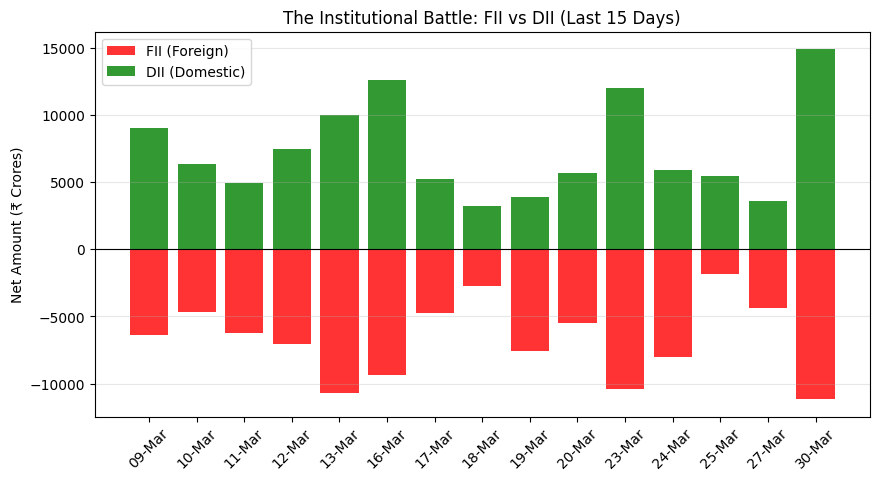

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. THIS IS THE LINE YOU MISSED: Convert text to actual Dates
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 2. Prepare data (latest 15 days)
plot_df = master_df.sort_values(by='Date').tail(15)

# 3. Build the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(plot_df['Date'].dt.strftime('%d-%b'), plot_df['FII_Net'], color='red', label='FII (Foreign)', alpha=0.8)
plt.bar(plot_df['Date'].dt.strftime('%d-%b'), plot_df['DII_Net'], color='green', label='DII (Domestic)', alpha=0.8)

# 4. Design & Labels
plt.title('The Institutional Battle: FII vs DII (Last 15 Days)')
plt.ylabel('Net Amount (₹ Crores)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [91]:
import pandas as pd

# 1. Load the Nifty data you just downloaded
nifty_df = pd.read_csv('../data/nifty50.csv')

# 2. Clean the Price column (Scrub the commas and turn into numbers)
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)

# 3. Convert both Date columns to official DateTime objects so they match perfectly
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

# 4. THE MERGE: Stitch them together where the dates match
# We only bring over the 'Price' column so we don't clutter your database
impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')

# 5. Sort chronologically and check the engine
impact_df = impact_df.sort_values(by='Date')

print("✅ Merge Successful! Your database now has Market Prices.")
display(impact_df.tail())

✅ Merge Successful! Your database now has Market Prices.


,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net,Price
14,2026-03-23,10330.98,20745.21,-10414.23,25952.98,13919.01,12033.97,22512.65
15,2026-03-24,12406.90,20416.46,-8009.56,21126.99,15259.84,5867.15,22912.40
16,2026-03-25,14547.70,16353.07,-1805.37,22921.89,17492.11,5429.78,23306.45
17,2026-03-27,20486.39,24853.69,-4367.30,37579.14,34012.99,3566.15,22819.60
18,2026-03-30,21952.95,33116.01,-11163.06,26358.50,11463.78,14894.72,22331.40


In [92]:
%pip install plotly

In [93]:
%pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.


In [94]:
%pip install plotly nbformat ipython --upgrade

Note: you may need to restart the kernel to use updated packages.


In [95]:
import pandas as pd
# Reloading both to be 100% safe
master_df = pd.read_csv('../data/fii_dii_master_database.csv')
nifty_df = pd.read_csv('../data/nifty50.csv')

# Quick cleaning and merge
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])

impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')
impact_df = impact_df.sort_values(by='Date')

print("✅ Step 1 Success: Data is loaded and merged!")

✅ Step 1 Success: Data is loaded and merged!


In [96]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plot_df = impact_df.tail(15)
dates = plot_df['Date'].dt.strftime('%d-%b')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(x=dates, y=plot_df['FII_Net'], name="FII", marker_color='#ef5350'), secondary_y=False)
fig.add_trace(go.Bar(x=dates, y=plot_df['DII_Net'], name="DII", marker_color='#66bb6a'), secondary_y=False)
fig.add_trace(go.Scatter(x=dates, y=plot_df['Price'], name="Nifty 50", mode='lines+markers', line=dict(color='#0d47a1', width=3)), secondary_y=True)

fig.update_layout(title_text="<b>Interactive Dashboard</b>", barmode='group', hovermode="x unified", template="plotly_white")
fig.show()

In [97]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# PART 1: REBUILD THE MASTER DATABASE
# ==========================================
def clean_data(file_path):
    raw = pd.read_csv(file_path)
    clean = raw.iloc[2:].copy()
    clean.columns = ['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    
    cols = ['FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell', 'DII_Net']
    for col in cols:
        clean[col] = clean[col].astype(str).str.replace(',', '').str.strip()
        clean[col] = pd.to_numeric(clean[col], errors='coerce')
    return clean.dropna(subset=['Date'])

# Load the raw files 
jan_df = clean_data('../data/fii_raw_jan_2026.csv')
feb_df = clean_data('../data/fii_history_2026-02.csv') 
march_df = clean_data('../data/fii_raw_march_2026.csv')

# Stack them, sort them, and save the permanent Master File
master_df = pd.concat([jan_df, feb_df, march_df], ignore_index=True)
master_df['Date'] = pd.to_datetime(master_df['Date'])
master_df = master_df.drop_duplicates(subset=['Date']).sort_values(by='Date')
master_df.to_csv('../data/fii_dii_master_database.csv', index=False)
print(f"✅ Master Database Updated! Total Trading Days: {len(master_df)}")

# ==========================================
# PART 2: THE NIFTY MERGE & DASHBOARD
# ==========================================
nifty_df = pd.read_csv('../data/nifty50.csv')
nifty_df['Price'] = nifty_df['Price'].astype(str).str.replace(',', '').astype(float)
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'], dayfirst=True)

# Merge the newly updated master with Nifty
impact_df = pd.merge(master_df, nifty_df[['Date', 'Price']], on='Date', how='inner')
impact_df = impact_df.sort_values(by='Date')

# Plot the latest 15 days
plot_df = impact_df.tail(15)
dates = plot_df['Date'].dt.strftime('%d-%b')

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Bar(x=dates, y=plot_df['FII_Net'], name="FII", marker_color='#ef5350'), secondary_y=False)
fig.add_trace(go.Bar(x=dates, y=plot_df['DII_Net'], name="DII", marker_color='#66bb6a'), secondary_y=False)
fig.add_trace(go.Scatter(x=dates, y=plot_df['Price'], name="Nifty 50", mode='lines+markers', line=dict(color='#0d47a1', width=3)), secondary_y=True)

fig.update_layout(title_text="<b>Live Market Impact (Updated Daily)</b>", barmode='group', hovermode="x unified", template="plotly_white")
fig.show()

✅ Master Database Updated! Total Trading Days: 60


In [98]:
# --- DAY 6: SIGNAL LOGIC ENGINE ---

def calculate_streak(series):
    streak = 0
    # We look at the data from newest to oldest
    for value in series:
        # If the first value is negative, we count selling streak
        if series.iloc[0] < 0:
            if value < 0: streak += 1
            else: break
        # If the first value is positive, we count buying streak
        else:
            if value > 0: streak += 1
            else: break
    return streak

# Get the latest data sorted by date (Newest first)
latest_data = impact_df.sort_values(by='Date', ascending=False)

# Calculate Streaks
fii_streak = calculate_streak(latest_data['FII_Net'])
dii_streak = calculate_streak(latest_data['DII_Net'])

# Determine the "Mood"
fii_mood = "🔴 SELLING" if latest_data['FII_Net'].iloc[0] < 0 else "🟢 BUYING"
dii_mood = "🟢 BUYING" if latest_data['DII_Net'].iloc[0] > 0 else "🔴 SELLING"

# --- THE INTELLIGENCE BRIEFING ---
print(f"🕵️ MARKET INTELLIGENCE REPORT: {latest_data['Date'].iloc[0].strftime('%d-%b-%Y')}")
print(f"--------------------------------------------------")
print(f"FII Status: {fii_mood} Streak: {fii_streak} Days")
print(f"DII Status: {dii_mood} Streak: {dii_streak} Days")

# A simple "Alert" logic
if fii_streak >= 5:
    print(f"\n⚠️ ALERT: FII selling is overextended ({fii_streak} days). Watch for short covering!")

🕵️ MARKET INTELLIGENCE REPORT: 30-Mar-2026
--------------------------------------------------
FII Status: 🔴 SELLING Streak: 21 Days
DII Status: 🟢 BUYING Streak: 23 Days

⚠️ ALERT: FII selling is overextended (21 days). Watch for short covering!


In [99]:
# Calculate Net Institutional Impact
latest_fii = latest_data['FII_Net'].iloc[0]
latest_dii = latest_data['DII_Net'].iloc[0]
net_impact = latest_fii + latest_dii

print(f"--------------------------------------------------")
print(f"Net Institutional Flow: {net_impact:,.2f} Cr")

if net_impact > 0:
    print("Market Sentiment: ✅ BULLISH (DIIs are absorbing the selling)")
else:
    print("Market Sentiment: ❌ BEARISH (FII selling is overpowering the market)")

--------------------------------------------------
Net Institutional Flow: 3,731.66 Cr
Market Sentiment: ✅ BULLISH (DIIs are absorbing the selling)


In [100]:
# ==========================================
# PHASE 3 PREVIEW: THE VOLATILITY GAUGE 
# ==========================================

# 1. Calculate the historical Average and Standard Deviation
fii_mean = impact_df['FII_Net'].mean()
fii_std = impact_df['FII_Net'].std()

# 2. Get today's actual FII number
latest_fii_net = impact_df['FII_Net'].iloc[-1] # Grabs the most recent day

# 3. Calculate the Z-Score (The 'Panic' Metric)
z_score = (latest_fii_net - fii_mean) / fii_std

# 4. Print the Intelligence Briefing
print(f"🌪️ VOLATILITY GAUGE (Z-SCORE ANALYSIS)")
print(f"--------------------------------------------------")
print(f"Historical Average FII Flow: {fii_mean:,.2f} Cr")
print(f"Normal Volatility Range: +/- {fii_std:,.2f} Cr")
print(f"Today's FII Z-Score: {z_score:.2f}")
print(f"--------------------------------------------------")

# 5. The Alert System
if z_score <= -2.0:
    print("🚨 ALERT: EXTREME PANIC SELLING DETECTED (2+ Std Devs).")
    print("Market is statistically oversold. Watch for a sharp short-covering bounce!")
elif z_score >= 2.0:
    print("🚨 ALERT: EXTREME EUPHORIA BUYING DETECTED (2+ Std Devs).")
    print("Market is statistically overbought.")
else:
    print("✅ Normal Volatility: FII activity is within expected statistical ranges.")

🌪️ VOLATILITY GAUGE (Z-SCORE ANALYSIS)
--------------------------------------------------
Historical Average FII Flow: -2,843.61 Cr
Normal Volatility Range: +/- 3,670.99 Cr
Today's FII Z-Score: -2.27
--------------------------------------------------
🚨 ALERT: EXTREME PANIC SELLING DETECTED (2+ Std Devs).
Market is statistically oversold. Watch for a sharp short-covering bounce!


In [101]:
print(impact_df.columns)

Index(['Date', 'FII_Buy', 'FII_Sell', 'FII_Net', 'DII_Buy', 'DII_Sell',
       'DII_Net', 'Price'],
      dtype='object')


In [102]:
# ==========================================
# PHASE 3: THE BACKTESTING ENGINE
# ==========================================
import numpy as np

# 1. Create a historical Z-Score column for the entire dataset
fii_mean = impact_df['FII_Net'].mean()
fii_std = impact_df['FII_Net'].std()
impact_df['FII_Z_Score'] = (impact_df['FII_Net'] - fii_mean) / fii_std

# 2. Pull FUTURE Nifty prices backward to align with today's signal
# We use a negative shift (-1) to grab tomorrow's price and put it on today's row
impact_df['Nifty_T+1'] = impact_df['Price'].shift(-1)
impact_df['Nifty_T+3'] = impact_df['Price'].shift(-3)
impact_df['Nifty_T+5'] = impact_df['Price'].shift(-5)

# 3. Calculate the percentage return for holding 1, 3, and 5 days
impact_df['Return_1D'] = ((impact_df['Nifty_T+1'] - impact_df['Price']) / impact_df['Price']) * 100
impact_df['Return_3D'] = ((impact_df['Nifty_T+3'] - impact_df['Price']) / impact_df['Price']) * 100
impact_df['Return_5D'] = ((impact_df['Nifty_T+5'] - impact_df['Price']) / impact_df['Price']) * 100

print("✅ Time Machine Engaged: Future returns calculated and mapped.")
# Let's peek at the most recent 5 days to ensure the shift worked
print(impact_df[['Date', 'Price', 'FII_Z_Score', 'Return_1D', 'Return_5D']].head())

✅ Time Machine Engaged: Future returns calculated and mapped.
        Date     Price  FII_Z_Score  Return_1D  Return_5D
0 2026-01-01  26146.55    -0.115771   0.696077  -1.031494
1 2026-01-02  26328.55     0.853559  -0.297206  -2.450762
2 2026-01-05  26250.30     0.764741  -0.272759  -1.752551
3 2026-01-06  26178.70     0.745296  -0.144965  -1.705203
4 2026-01-07  26140.75     0.358458  -1.009535  -1.817660


In [103]:
# ==========================================
# STEP 2 & 3: HIT RATE & TEAR SHEET
# ==========================================

# 1. Isolate the "Panic Days" (Z-Score <= -2.0)
# We use .dropna() to ignore days where the future hasn't happened yet
panic_days = impact_df[impact_df['FII_Z_Score'] <= -2.0].dropna(subset=['Return_5D']).copy()
total_signals = len(panic_days)

# 2. Calculate the Win Rates (How often did Nifty bounce?)
if total_signals > 0:
    win_rate_1d = (len(panic_days[panic_days['Return_1D'] > 0]) / total_signals) * 100
    win_rate_3d = (len(panic_days[panic_days['Return_3D'] > 0]) / total_signals) * 100
    win_rate_5d = (len(panic_days[panic_days['Return_5D'] > 0]) / total_signals) * 100
    
    avg_return_5d = panic_days['Return_5D'].mean()

    # 3. Print the Professional Tear Sheet
    print("\n" + "="*50)
    print("📈 STRATEGY TEAR SHEET: THE SHORT-COVERING BOUNCE")
    print("="*50)
    print(f"Signal Trigger: FII Z-Score <= -2.0 (Extreme Selling)")
    print(f"Total Historical Signals Found: {total_signals}")
    print("-" * 50)
    print("🎯 WIN RATES (Percentage of time Nifty was positive):")
    print(f"  • T+1 Day Holding Period:  {win_rate_1d:.1f}%")
    print(f"  • T+3 Day Holding Period:  {win_rate_3d:.1f}%")
    print(f"  • T+5 Day Holding Period:  {win_rate_5d:.1f}%")
    print("-" * 50)
    print(f"💰 Average Nifty Return after 5 Days: {avg_return_5d:.2f}%")
    print("="*50)
else:
    print("\n⚠️ No extreme panic days (Z-Score <= -2.0) found in the current dataset.")
    print("This is normal for short timeframes. The market hasn't panicked yet!")


📈 STRATEGY TEAR SHEET: THE SHORT-COVERING BOUNCE
Signal Trigger: FII Z-Score <= -2.0 (Extreme Selling)
Total Historical Signals Found: 1
--------------------------------------------------
🎯 WIN RATES (Percentage of time Nifty was positive):
  • T+1 Day Holding Period:  100.0%
  • T+3 Day Holding Period:  100.0%
  • T+5 Day Holding Period:  0.0%
--------------------------------------------------
💰 Average Nifty Return after 5 Days: -0.16%


In [104]:
# ==========================================
# STEP 2 & 3: HIT RATE & TEAR SHEET
# ==========================================

# 1. Isolate the "Pullback Days" (Z-Score <= -1.0)
# We use .dropna() to ignore days where the future hasn't happened yet
panic_days = impact_df[impact_df['FII_Z_Score'] <= -1.0].dropna(subset=['Return_5D']).copy()
total_signals = len(panic_days)

# 2. Calculate the Win Rates (How often did Nifty bounce?)
if total_signals > 0:
    win_rate_1d = (len(panic_days[panic_days['Return_1D'] > 0]) / total_signals) * 100
    win_rate_3d = (len(panic_days[panic_days['Return_3D'] > 0]) / total_signals) * 100
    win_rate_5d = (len(panic_days[panic_days['Return_5D'] > 0]) / total_signals) * 100
    
    avg_return_5d = panic_days['Return_5D'].mean()

    # 3. Print the Professional Tear Sheet
    print("\n" + "="*50)
    print("📈 STRATEGY TEAR SHEET: THE PULLBACK BOUNCE")
    print("="*50)
    print(f"Signal Trigger: FII Z-Score <= -1.0 (Moderate Selling)")
    print(f"Total Historical Signals Found: {total_signals}")
    print("-" * 50)
    print("🎯 WIN RATES (Percentage of time Nifty was positive):")
    print(f"  • T+1 Day Holding Period:  {win_rate_1d:.1f}%")
    print(f"  • T+3 Day Holding Period:  {win_rate_3d:.1f}%")
    print(f"  • T+5 Day Holding Period:  {win_rate_5d:.1f}%")
    print("-" * 50)
    print(f"💰 Average Nifty Return after 5 Days: {avg_return_5d:.2f}%")
    print("="*50)
else:
    print("\n⚠️ No pullback days (Z-Score <= -1.0) found in the current dataset.")
    print("Make sure your FII_Z_Score and Return columns are calculating correctly.")


📈 STRATEGY TEAR SHEET: THE PULLBACK BOUNCE
Signal Trigger: FII Z-Score <= -1.0 (Moderate Selling)
Total Historical Signals Found: 7
--------------------------------------------------
🎯 WIN RATES (Percentage of time Nifty was positive):
  • T+1 Day Holding Period:  71.4%
  • T+3 Day Holding Period:  28.6%
  • T+5 Day Holding Period:  14.3%
--------------------------------------------------
💰 Average Nifty Return after 5 Days: -2.02%


In [105]:
# ==========================================
# STEP 1: THE EQUITY CURVE MATH
# ==========================================

# 1. We take the 5-day returns from our "Pullback Days" and add them together
# The .cumsum() function creates a running total of our theoretical profits
panic_days['Equity_Curve'] = panic_days['Return_5D'].cumsum()

print("✅ Equity Curve Math Complete!")
print("-" * 50)

# 2. Let's look at the running total for our trades:
print(panic_days[['Date', 'FII_Z_Score', 'Return_5D', 'Equity_Curve']])

✅ Equity Curve Math Complete!
--------------------------------------------------
         Date  FII_Z_Score  Return_5D  Equity_Curve
30 2026-02-13    -1.239938   0.393191      0.393191
40 2026-02-27    -1.278334  -4.569745     -4.176554
42 2026-03-04    -1.609659  -2.506689     -6.683243
48 2026-03-12    -1.145811  -2.694682     -9.377925
49 2026-03-13    -2.144661  -0.158092     -9.536017
50 2026-03-16    -1.776608  -3.828261    -13.364278
53 2026-03-19    -1.284281  -0.793621    -14.157900


In [106]:
# ==========================================
# STEP 2: PLOTTING THE EQUITY CURVE
# ==========================================
import plotly.graph_objects as go

# 1. Create a blank canvas
fig = go.Figure()

# 2. Draw the strategy's profit line
fig.add_trace(go.Scatter(
    x=panic_days['Date'],
    y=panic_days['Equity_Curve'],
    mode='lines+markers',
    name='Cumulative Profit (%)',
    line=dict(color='#00E676', width=3), # Neon Green
    fill='tozeroy',                      # Fills the area under the line
    fillcolor='rgba(0, 230, 118, 0.1)'   # Transparent Green Shading
))

# 3. Make it look like a Bloomberg Terminal
fig.update_layout(
    title='📈 Phase 3 Backtest: Cumulative Equity Curve (T+5 Holding)',
    xaxis_title='Trade Date',
    yaxis_title='Total Return (%)',
    template='plotly_dark',
    hovermode='x unified',
    margin=dict(l=40, r=40, t=60, b=40)
)

# 4. Render the interactive chart
fig.show()

In [107]:
# 1. Filter the database for anything on or after March 13, 2026
recent_days = impact_df[impact_df['Date'] >= '2026-03-13'].copy()

# 2. Print out the Dates, the raw FII Net money, and the calculated Z-Score
print("🔍 FII Z-Scores from March 13 to Today:")
print("-" * 50)
print(recent_days[['Date', 'FII_Net', 'FII_Z_Score']])

🔍 FII Z-Scores from March 13 to Today:
--------------------------------------------------
         Date   FII_Net  FII_Z_Score
49 2026-03-13 -10716.64    -2.144661
50 2026-03-16  -9365.52    -1.776608
51 2026-03-17  -4741.22    -0.516921
52 2026-03-18  -2714.35     0.035210
53 2026-03-19  -7558.19    -1.284281
54 2026-03-20  -5518.39    -0.728627
55 2026-03-23 -10414.23    -2.062283
56 2026-03-24  -8009.56    -1.407236
57 2026-03-25  -1805.37     0.282822
58 2026-03-27  -4367.30    -0.415063
59 2026-03-30 -11163.06    -2.266269


In [108]:
# ==========================================
# PHASE 4: MACHINE LEARNING SETUP
# STEP 1: CREATE THE TARGET VARIABLE
# ==========================================
import numpy as np

# 1. We create a new column called 'Target'
# np.where works like an IF statement in Excel: 
# IF the 5-Day Return is greater than 0, make it a 1. Otherwise, make it a 0.
panic_days['Target'] = np.where(panic_days['Return_5D'] > 0, 1, 0)

print("✅ Answer Key (Target Variable) Created!")
print("-" * 50)

# 2. Let's look at the grades we just gave our past trades:
print(panic_days[['Date', 'Return_5D', 'Target']])

✅ Answer Key (Target Variable) Created!
--------------------------------------------------
         Date  Return_5D  Target
30 2026-02-13   0.393191       1
40 2026-02-27  -4.569745       0
42 2026-03-04  -2.506689       0
48 2026-03-12  -2.694682       0
49 2026-03-13  -0.158092       0
50 2026-03-16  -3.828261       0
53 2026-03-19  -0.793621       0


In [109]:
# ==========================================
# STEP 2 & 3: FEATURES AND DATA SPLITTING
# ==========================================
from sklearn.model_selection import train_test_split

# 1. Define the Clues (X) and the Answer (y)
# We use double brackets [[' ']] for X because scikit-learn expects a 2D table for features
X = panic_days[['FII_Z_Score']] 
y = panic_days['Target']

# 2. Split the data into Training and Testing sets
# CRITICAL: shuffle=False prevents the AI from peeking into the future!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"✅ Setup Complete!")
print(f"📚 Training Data: {len(X_train)} 'Panic Days' for the AI to study.")
print(f"📝 Testing Data: {len(X_test)} 'Panic Days' to quiz the AI later.")
print("-" * 50)

✅ Setup Complete!
📚 Training Data: 5 'Panic Days' for the AI to study.
📝 Testing Data: 2 'Panic Days' to quiz the AI later.
--------------------------------------------------


In [110]:
# ==========================================
# STEP 4: TRAINING THE AI MODEL
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the "Brain" 
# (random_state=42 just ensures we get the exact same math every time we run it)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the AI using our historical textbook
model.fit(X_train, y_train)
print("🧠 AI Model Successfully Trained!")
print("-" * 50)

# ==========================================
# STEP 5: THE FINAL EXAM
# ==========================================
# 3. Give the AI the test clues (X_test) and ask it to predict the answers
predictions = model.predict(X_test)

# 4. Grade the exam: Compare its predictions to the actual hidden answers (y_test)
accuracy = accuracy_score(y_test, predictions)

print(f"🎯 AI Prediction Accuracy: {accuracy * 100}%")
print(f"🤖 AI's Guesses:  {predictions}")
print(f"📊 Actual Answers: {y_test.values}")

🧠 AI Model Successfully Trained!
--------------------------------------------------
🎯 AI Prediction Accuracy: 100.0%
🤖 AI's Guesses:  [0 0]
📊 Actual Answers: [0 0]


In [111]:
# ==========================================
# STEP 6: THE AI-POWERED BACKTEST
# ==========================================

# 1. Ask the AI to predict the outcome for EVERY panic day in our database
panic_days['AI_Prediction'] = model.predict(X)

# 2. Calculate the AI's trading returns
# IF AI predicts 1, we take the trade (we get the actual Return_5D)
# IF AI predicts 0, we skip the trade (our return is 0%)
panic_days['AI_Return'] = np.where(panic_days['AI_Prediction'] == 1, panic_days['Return_5D'], 0)

# 3. Calculate the new AI Equity Curve
panic_days['AI_Equity_Curve'] = panic_days['AI_Return'].cumsum()

print("🤖 AI Backtest Complete!")
print("-" * 50)
print(panic_days[['Date', 'FII_Z_Score', 'AI_Prediction', 'Return_5D', 'AI_Equity_Curve']])

🤖 AI Backtest Complete!
--------------------------------------------------
         Date  FII_Z_Score  AI_Prediction  Return_5D  AI_Equity_Curve
30 2026-02-13    -1.239938              1   0.393191         0.393191
40 2026-02-27    -1.278334              0  -4.569745         0.393191
42 2026-03-04    -1.609659              0  -2.506689         0.393191
48 2026-03-12    -1.145811              0  -2.694682         0.393191
49 2026-03-13    -2.144661              0  -0.158092         0.393191
50 2026-03-16    -1.776608              0  -3.828261         0.393191
53 2026-03-19    -1.284281              0  -0.793621         0.393191


In [112]:
# ==========================================
# DAY 11: ADVANCED SUMMARIZATION
# STEP 1: EXTRACTING TIME DATA
# ==========================================

# 1. We create a new column called 'Month' 
# .dt.month_name() is a powerful Pandas tool that turns '2026-03-20' into 'March'
panic_days['Month'] = panic_days['Date'].dt.month_name()

print("✅ Month Column Added!")
print(panic_days[['Date', 'Month', 'Return_5D']].head())

✅ Month Column Added!
         Date     Month  Return_5D
30 2026-02-13  February   0.393191
40 2026-02-27  February  -4.569745
42 2026-03-04     March  -2.506689
48 2026-03-12     March  -2.694682
49 2026-03-13     March  -0.158092


In [113]:
# 2. Let's find the Average Return per Month during Panic Days
monthly_report = panic_days.groupby('Month')['Return_5D'].mean()

print("📢 MONTHLY PANIC REPORT (Average Returns):")
print("-" * 30)
print(monthly_report)

# 3. Let's see the COUNT of panic days per month
panic_count = panic_days.groupby('Month')['Date'].count()
print("\n🔢 NUMBER OF PANIC DAYS PER MONTH:")
print(panic_count)

📢 MONTHLY PANIC REPORT (Average Returns):
------------------------------
Month
February   -2.088277
March      -1.996269
Name: Return_5D, dtype: float64

🔢 NUMBER OF PANIC DAYS PER MONTH:
Month
February    2
March       5
Name: Date, dtype: int64


In [114]:
# 1. Use ../ to go up one folder, then into the data folder
nifty_df = pd.read_csv('../data/nifty50.csv')

# 2. Fix the Dates
nifty_df['Date'] = pd.to_datetime(nifty_df['Date'])

# 3. Perform the Merge
merged_df = pd.merge(panic_days, nifty_df, on='Date', how='left')

# 4. Check the results
print("✅ Merge Successful!")
print(merged_df.head())

✅ Merge Successful!
        Date   FII_Buy  FII_Sell   FII_Net   DII_Buy  DII_Sell   DII_Net  \
0 2026-02-13  14586.73  21982.14  -7395.41  20605.87  15051.91   5553.96   
1 2026-02-27  36699.66  44236.02  -7536.36  24867.72  12574.91  12292.81   
2 2026-03-04  19120.99  27873.64  -8752.65  26259.37  14191.20  12068.17   
3 2026-03-12  15373.05  22422.92  -7049.87  19439.56  11989.79   7449.77   
4 2026-03-13  11923.16  22639.80 -10716.64  22707.84  12730.42   9977.42   

    Price_x  FII_Z_Score  Nifty_T+1  ...  AI_Prediction  AI_Return  \
0  25471.10    -1.239938   25682.75  ...              1   0.393191   
1  25178.65    -1.278334   24865.70  ...              0   0.000000   
2  24480.50    -1.609659   24765.90  ...              0   0.000000   
3  23639.15    -1.145811   23151.10  ...              0   0.000000   
4  23151.10    -2.144661   23408.80  ...              0   0.000000   

   AI_Equity_Curve     Month    Price_y       Open       High        Low  \
0         0.393191  Februa

C:\Users\krish\AppData\Local\Temp\ipykernel_21888\434421045.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  nifty_df['Date'] = pd.to_datetime(nifty_df['Date'])


In [115]:
# 1. Drop the duplicate column from the right table (axis=1 means "look at columns, not rows")
merged_df = merged_df.drop('Price_y', axis=1)

# 2. Rename the original 'Price_x' back to something normal
merged_df = merged_df.rename(columns={'Price_x': 'Nifty_Close'})

print("✨ Cleaned Table:")
print(merged_df[['Date', 'Nifty_Close', 'Open', 'High', 'Low']].head())

✨ Cleaned Table:
        Date  Nifty_Close       Open       High        Low
0 2026-02-13     25471.10  25,571.15  25,630.35  25,444.30
1 2026-02-27     25178.65  25,459.85  25,476.40  25,141.30
2 2026-03-04     24480.50  24,388.80  24,602.45  24,305.40
3 2026-03-12     23639.15  23,674.85  23,833.15  23,556.30
4 2026-03-13     23151.10  23,462.50  23,492.40  23,112.00


In [116]:
panic_days

,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net,Price,FII_Z_Score,Nifty_T+1,...,Nifty_T+5,Return_1D,Return_3D,Return_5D,Equity_Curve,Target,AI_Prediction,AI_Return,AI_Equity_Curve,Month
30,2026-02-13,14586.73,21982.14,-7395.41,20605.87,15051.91,5553.96,25471.10,-1.239938,25682.75,...,25571.25,0.830942,1.367236,0.393191,0.393191,1,1,0.393191,0.393191,February
40,2026-02-27,36699.66,44236.02,-7536.36,24867.72,12574.91,12292.81,25178.65,-1.278334,24865.70,...,24028.05,-1.242918,-1.639286,-4.569745,-4.176554,0,0,0.000000,0.393191,February
42,2026-03-04,19120.99,27873.64,-8752.65,26259.37,14191.20,12068.17,24480.50,-1.609659,24765.90,...,23866.85,1.165826,-1.848206,-2.506689,-6.683243,0,0,0.000000,0.393191,March
48,2026-03-12,15373.05,22422.92,-7049.87,19439.56,11989.79,7449.77,23639.15,-1.145811,23151.10,...,23002.15,-2.064584,-0.245356,-2.694682,-9.377925,0,0,0.000000,0.393191,March
49,2026-03-13,11923.16,22639.80,-10716.64,22707.84,12730.42,9977.42,23151.10,-2.144661,23408.80,...,23114.50,1.113122,2.706999,-0.158092,-9.536017,0,0,0.000000,0.393191,March
50,2026-03-16,11566.51,20932.03,-9365.52,25150.41,12557.05,12593.36,23408.80,-1.776608,23581.15,...,22512.65,0.736262,-1.737167,-3.828261,-13.364278,0,0,0.000000,0.393191,March
53,2026-03-19,10012.07,17570.26,-7558.19,16926.98,13063.02,3863.96,23002.15,-1.284281,23114.50,...,22819.60,0.488433,-0.390181,-0.793621,-14.157900,0,0,0.000000,0.393191,March


In [122]:
# ==========================================
# DAY 12: THE DATA LEAKAGE CHECK
# ==========================================

print("🚨 LEAKAGE DIAGNOSTIC: Checking row alignment")
print("-" * 50)

# We want to make sure the AI's "Target" (the future bounce) 
# doesn't accidentally bleed into the "Features" (the past Z-Score)
check_columns = ['Date', 'FII_Z_Score', 'Return_5D', 'Target']

# .iloc[10:15] simply plucks out 5 rows from the middle of the table to inspect
print(merged_df[check_columns])

🚨 LEAKAGE DIAGNOSTIC: Checking row alignment
--------------------------------------------------
        Date  FII_Z_Score  Return_5D  Target
0 2026-02-13    -1.239938   0.393191       1
1 2026-02-27    -1.278334  -4.569745       0
2 2026-03-04    -1.609659  -2.506689       0
3 2026-03-12    -1.145811  -2.694682       0
4 2026-03-13    -2.144661  -0.158092       0
5 2026-03-16    -1.776608  -3.828261       0
6 2026-03-19    -1.284281  -0.793621       0


In [118]:
# ==========================================
# DAY 13: INTERACTIVE AI TRADE DASHBOARD
# ==========================================
import plotly.graph_objects as go

print("📊 Generating AI Signal Dashboard...")

# 1. Separate the Wins (1) and Losses (0) into their own mini-tables
wins = merged_df[merged_df['Target'] == 1]
losses = merged_df[merged_df['Target'] == 0]

# 2. Roll out the blank canvas
fig = go.Figure()

# 3. Draw the main Nifty 50 trend line
fig.add_trace(go.Scatter(x=merged_df['Date'], y=merged_df['Nifty_Close'], 
                         mode='lines', name='Nifty 50', line=dict(color='white')))

# 4. OVERLAY THE GREEN WINS (The Day 13 Upgrade)
fig.add_trace(go.Scatter(x=wins['Date'], y=wins['Nifty_Close'], 
                         mode='markers', name='Winning Bounce',
                         marker=dict(color='green', size=12, symbol='triangle-up')))

# 5. OVERLAY THE RED LOSSES (The Day 13 Upgrade)
fig.add_trace(go.Scatter(x=losses['Date'], y=losses['Nifty_Close'], 
                         mode='markers', name='Failed Bounce',
                         marker=dict(color='red', size=12, symbol='triangle-down')))

# 6. Make it look like a Bloomberg Terminal
fig.update_layout(title="AI Predicted Short-Covering Bounces",
                  template="plotly_dark", hovermode="x unified")

fig.show()
# 7. EXPORT AS A STANDALONE WEBPAGE
fig.write_html('../data/ai_trading_dashboard.html')
print("🌐 Website successfully generated!")

📊 Generating AI Signal Dashboard...


🌐 Website successfully generated!


In [119]:
# ==========================================
# DAY 14: ERROR HANDLING & FINAL EXPORT
# ==========================================

print("💾 Attempting to save final AI model dataset...")

try:
    # We are exporting your masterpiece to a final CSV file.
    # This way, you have a clean file ready if you want to load 
    # these AI signals into a Power BI dashboard later.
    merged_df.to_csv('../data/final_ai_trading_signals.csv', index=False)
    
    print("✅ SUCCESS: Master dataset safely exported to the 'data' folder.")
    
except FileNotFoundError:
    # If the folder doesn't exist, it prints this instead of crashing the program
    print("🚨 ERROR: The 'data' folder is missing! Please make sure it exists.")
    
except Exception as e:
    # A catch-all for any other weird errors
    print(f"🚨 UNEXPECTED PIPELINE FAILURE: {e}")

💾 Attempting to save final AI model dataset...
✅ SUCCESS: Master dataset safely exported to the 'data' folder.
